In [1]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn

## Checking CUDA availability

In [2]:
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
  print(f"GPU Detected: {torch.cuda.get_device_name(0)}")
else:
  print("PyTorch cannot see the GPU.")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
GPU Detected: NVIDIA GeForce RTX 3050 Laptop GPU


## Loading the datasets

In [3]:
print("Loading the numpy arrays into RAM...")
X=np.load("./data/features/X_data.npy")
y=np.load("./data/features/y_labels.npy")
print("Successfully loaded the numpy arrays into the RAM!")

Loading the numpy arrays into RAM...
Successfully loaded the numpy arrays into the RAM!


## Splitting the data (80% Training, 20% Validation)

In [4]:
X_train, X_val, y_train, y_val=train_test_split(X, y, test_size=0.2, stratify=y)

## Converting the numpy arrays to PyTorch Float32 tensors

In [5]:
print("Converting the numpy arrays into pytorch tensors....")
tensor_X_train=torch.tensor(X_train, dtype=torch.float32)
tensor_X_val=torch.tensor(X_val, dtype=torch.float32)
tensor_y_train=torch.tensor(y_train, dtype=torch.float32)
tensor_y_val=torch.tensor(y_val, dtype=torch.float32)
print("Successfully converted the numpy arrays into float32 pytorch tensors.")

Converting the numpy arrays into pytorch tensors....
Successfully converted the numpy arrays into float32 pytorch tensors.


## Wrapping into datasets

In [6]:
training_dataset=TensorDataset(tensor_X_train,tensor_y_train)
validation_dataset=TensorDataset(tensor_X_val, tensor_y_val)

## Building the DataLoaders

In [7]:
batch_size=128
training_dataset_loader=DataLoader(training_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
validation_dataset_loader=DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders ready with batch size of {batch_size}")
print(f"Batches in training dataset loader: {len(training_dataset_loader)} | Batches in validation dataset loader: {len(validation_dataset_loader)}")

for images, labels in training_dataset_loader:
  print(f"\nFirst batch image shape: {images.shape}")
  print(f"First batch label shape: {labels.shape}")
  break

DataLoaders ready with batch size of 128
Batches in training dataset loader: 272 | Batches in validation dataset loader: 69

First batch image shape: torch.Size([128, 1, 40, 201])
First batch label shape: torch.Size([128])


## The Neural Network Architecture (The Brain)

In [8]:
class AudioResNetBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()

    # 1st Convolution: Looks for patterns (lines, edges, frequencies)
    self.conv1=nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn1=nn.BatchNorm2d(out_channels)
    self.relu=nn.ReLU(inplace=True)

    # 2nd Convolution: Refines the patterns
    self.conv2=nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn2=nn.BatchNorm2d(out_channels)

    # ResNet Shortcut Connection
    self.shortcut=nn.Sequential()
    if stride!=1 or in_channels!=out_channels:
      # If the image shrank, we shrink the shortcut to match so we can add them together
      self.shortcut=nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
        nn.BatchNorm2d(out_channels)
      )

  def forward(self, x):
    residual=self.shortcut(x)

    out=self.conv1(x)
    out=self.bn1(out)
    out=self.relu(out)

    out=self.conv2(out)
    out=self.bn2(out)

    # Add the skipped signal back into the processed signal
    out+=residual
    out=self.relu(out)

    return out

In [9]:
class WakeWordBrain(nn.Module):
  def __init__(self):
    super().__init__()

    self.stem=nn.Sequential(
      nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False),
      nn.BatchNorm2d(16),
      nn.ReLU(inplace=True)
    )

    # 3 Blocks of ResNet. Each block makes the "image" smaller but deeper.
    self.layer1=AudioResNetBlock(16, 16, stride=1)
    self.layer2=AudioResNetBlock(16, 32, stride=2)
    self.layer3=AudioResNetBlock(32, 64, stride=2)

    self.adaptive_pool=nn.AdaptiveAvgPool2d((1, 1))

    self.classifier=nn.Linear(64, 1)

  def forward(self, x):
    x=self.stem(x)
    x=self.layer1(x)
    x=self.layer2(x)
    x=self.layer3(x)

    x=self.adaptive_pool(x)
    x=torch.flatten(x, 1) # Flatten from 2D to 1D

    # Final output is a raw number (called a logit). 
    # Positive number = "Hello Manas" | Negative number = Background Noise
    x=self.classifier(x)
    return x

In [10]:
device=("cuda" if torch.cuda.is_available() else "cpu")
print(f"Loading architecture to: {device}")

# Instantiate the neural network and move it to the GPU
model=WakeWordBrain().to(device)

# Total parameters
total_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

# Simulate a fake batch of audio to make sure the math works without crashing
dummy_batch = torch.randn(128, 1, 40, 201).to(device)
dummy_output = model(dummy_batch)
print(f"Brain output shape: {dummy_output.shape}")

Loading architecture to: cuda
Total Trainable Parameters: 77,169
Brain output shape: torch.Size([128, 1])


## Focal Loss

In [15]:
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import time

In [16]:
class BinaryFocalLoss(nn.Module):
  def __init__(self, alpha=0.25, gamma=2.0):
    super().__init__()
    self.alpha=alpha
    self.gamma=gamma

  def forward(self, inputs, targets):
    bce_loss=F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
    probs=torch.sigmoid(inputs)
    p_t=probs*targets+(1-probs)*(1-targets)

    focal_weight=(self.alpha*targets+(1-self.alpha)*(1-targets))*(1-p_t)**self.gamma

    return torch.mean(focal_weight*bce_loss)

## Training Loop

In [17]:
# Initialize the Loss and Optimizer
criterion=BinaryFocalLoss(alpha=0.75, gamma=2.0)
optimizer=optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

In [19]:
print("STARTING THE TRAINING LOOP....")

EPOCHS=10
best_val_accuracy=0.0

history = {
  'train_loss': [],
  'val_loss': [],
  'train_acc': [],
  'val_acc': []
}

for epoch in range(EPOCHS):
  start_time=time.time()

  model.train()
  train_loss=0.0
  train_correct=0
  train_total=0

  for images, labels in tqdm(training_dataset_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False):
    images, labels=images.to(device), labels.to(device)

    labels=labels.unsqueeze(1)

    # Forward Pass
    outputs=model(images)
    loss=criterion(outputs, labels)

    # Backward Pass
    optimizer.zero_grad()
    loss.backward()

    # Optimize (Update the parameters)
    optimizer.step()

    # Train metrics
    train_loss+=loss.item()
    preds=torch.round(torch.sigmoid(outputs)) # Convert raw numbers to 0 or 1
    train_correct+=(preds==labels).sum().item()
    train_total+=labels.size(0)
  
  average_train_loss=train_loss/len(training_dataset_loader)
  train_accuracy=(train_correct/train_total)*100

  # --- VALIDATION PHASE ---
  model.eval()
  val_loss=0.0
  val_correct=0
  val_total=0

  with torch.no_grad():
    for images, labels in validation_dataset_loader:
      images, labels=images.to(device), labels.to(device)
      labels=labels.unsqueeze(1)

      outputs=model(images)
      loss=criterion(outputs, labels)

      val_loss+=loss.item()
      preds=torch.round(torch.sigmoid(outputs))
      val_correct+=(preds==labels).sum().item()
      val_total+=labels.size(0)

  average_val_loss=val_loss/len(validation_dataset_loader)
  val_accuracy=(val_correct/val_total)*100
  epoch_time=time.time()-start_time

  history['train_loss'].append(average_train_loss)
  history['val_loss'].append(average_val_loss)
  history['train_acc'].append(train_accuracy)
  history['val_acc'].append(val_accuracy)

  print(f"Epoch {epoch+1}/{EPOCHS} | Time: {epoch_time:.1f}s")
  print(f"Train Loss: {average_train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
  print(f"Val Loss:   {average_val_loss:.4f} | Val Acc:   {val_accuracy:.2f}%")

  if val_accuracy>best_val_accuracy:
    best_val_accuracy=val_accuracy
    torch.save(model.state_dict(), "best_wakeword_brain.pth")
  print("-" * 50)

print(f"\n✅ TRAINING COMPLETE. Best Validation Accuracy: {best_val_accuracy:.2f}%")

STARTING THE TRAINING LOOP....


Epoch 1/10 | Time: 24.4s
Train Loss: 0.0036 | Train Acc: 99.00%
Val Loss:   0.0023 | Val Acc:   99.25%
--------------------------------------------------


Epoch 2/10 | Time: 24.4s
Train Loss: 0.0010 | Train Acc: 99.65%
Val Loss:   0.0027 | Val Acc:   99.55%
--------------------------------------------------


Epoch 3/10 | Time: 24.1s
Train Loss: 0.0010 | Train Acc: 99.72%
Val Loss:   0.0010 | Val Acc:   99.83%
--------------------------------------------------


Epoch 4/10 | Time: 24.2s
Train Loss: 0.0005 | Train Acc: 99.87%
Val Loss:   0.0006 | Val Acc:   99.85%
--------------------------------------------------


...

Epoch 6/10 | Time: 24.1s
Train Loss: 0.0005 | Train Acc: 99.84%
Val Loss:   0.0007 | Val Acc:   99.64%
--------------------------------------------------


Epoch 7/10 | Time: 24.1s
Train Loss: 0.0001 | Train Acc: 99.96%
Val Loss:   0.0001 | Val Acc:   99.99%
--------------------------------------------------


Epoch 8/10 | Time: 24.2s
Train Loss: 0.0003 | Train Acc: 99.88%
Val Loss:   0.0020 | Val Acc:   99.06%
--------------------------------------------------


Epoch 9/10 | Time: 24.2s
Train Loss: 0.0001 | Train Acc: 99.97%
Val Loss:   0.0000 | Val Acc:   99.99%
--------------------------------------------------


Epoch 10/10 | Time: 24.2s
Train Loss: 0.0021 | Train Acc: 99.43%
Val Loss:   0.0017 | Val Acc:   99.74%
--------------------------------------------------

✅ TRAINING COMPLETE. Best Validation Accuracy: 99.99%


## PLOTTING THE LEARNING CURVES

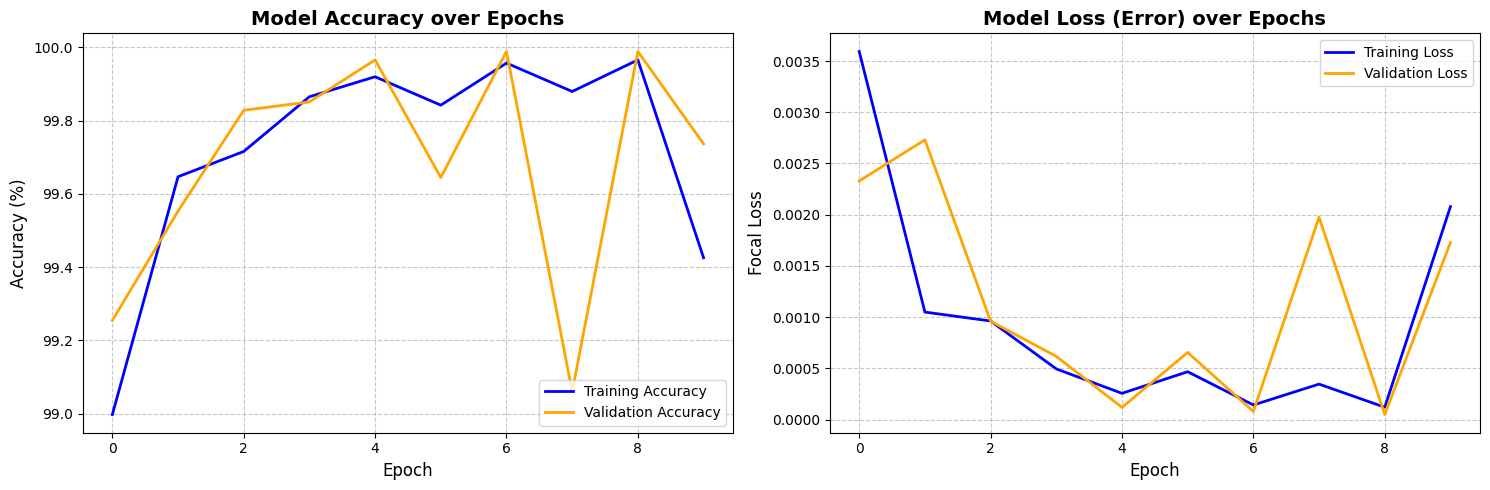

In [22]:
import matplotlib.pyplot as plt

# Set up a 1x2 grid of plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Plot the Accuracy (Markers removed, linewidth added for a sleek look)
ax1.plot(history['train_acc'], label='Training Accuracy', color='blue', linewidth=2)
ax1.plot(history['val_acc'], label='Validation Accuracy', color='orange', linewidth=2)
ax1.set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Plot the Loss (Error) (Markers removed, linewidth added)
ax2.plot(history['train_loss'], label='Training Loss', color='blue', linewidth=2)
ax2.plot(history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax2.set_title('Model Loss (Error) over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Focal Loss', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()